In [32]:
%load_ext autoreload
%autoreload 2

import torch

# from confusions import evaluate_and_report
# from data import load_mnist_normalized, split_train_dev_test, make_dataloaders
# from model import HyperParams, DNN
# from train_eval import train_model, evaluate_model
# from plots import plot_example_digits, plot_learning_curves
# from mnist_activations import visualize_activations_on_loader, visualize_activations_by_label

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# confusions.py

import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_report(model, dataloader, device="cpu", class_names=None):
    """
    model: trained PyTorch model
    dataloader: test DataLoader
    class_names: list of names for sklearn display (optional)
    """
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device).float()
            yb = yb.to(device).long()

            logits = model(xb)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # ---- Classification Report ----
    print("\nCLASSIFICATION REPORT\n")
    print(classification_report(all_labels, all_preds,
                                digits=5,
                                target_names=class_names))

    # ---- Confusion Matrix ----
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d")
    plt.xticks(rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return None



In [34]:
# data.py

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from torch.utils.data import Dataset, DataLoader


class MNISTDataset(Dataset):
    """Wraps numpy arrays as a PyTorch Dataset."""

    def __init__(self, input_data: np.ndarray, labels: np.ndarray):
        self.feats = input_data
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        X = self.feats[index]
        y = self.labels[index]
        return X, y


def load_mnist_normalized():
    """
    Load MNIST via fetch_openml and normalize to roughly [-1, 1].
    Returns X, y as numpy arrays.
    """
    mnist = fetch_openml("mnist_784", version=1)
    X, y = mnist["data"], mnist["target"]
    y = y.astype(int)

    # Your scaling: ((X / 255) - 0.5) * 2
    X = ((X / 255.0) - 0.5) * 2.0
    
    X_reshaped = X.to_numpy().reshape(-1, 1, 28, 28)

    return X_reshaped, y.to_numpy()


def split_train_dev_test(X, y, train_size=60000, random_state=12):
    """
    First 60k -> train+dev, last 10k -> test (as in original notebook).
    Then stratified split train->(train, dev).
    """
    X_train_full, X_test = X[:train_size], X[train_size:]
    y_train_full, y_test = y[:train_size], y[train_size:]

    splitter = StratifiedShuffleSplit(
        n_splits=1, test_size=0.1, random_state=random_state
    )
    (train_idx, dev_idx), = splitter.split(X_train_full, y_train_full)

    X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
    X_dev, y_dev = X_train_full[dev_idx], y_train_full[dev_idx]

    return (X_train, y_train), (X_dev, y_dev), (X_test, y_test)


def make_dataloaders(
    X_train,
    y_train,
    X_dev,
    y_dev,
    X_test,
    y_test,
    batch_size=64,
    test_batch_size=16,
):
    """Create PyTorch DataLoaders from numpy arrays."""
    train_set = MNISTDataset(X_train, y_train)
    dev_set = MNISTDataset(X_dev, y_dev)
    test_set = MNISTDataset(X_test, y_test)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        pin_memory=False,
    )

    dev_loader = DataLoader(
        dev_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        pin_memory=False,
    )

    test_loader = DataLoader(
        test_set,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=False,
        pin_memory=False,
    )

    return train_loader, dev_loader, test_loader


In [35]:
# mnist_activations.py

"""
Activation-visualization helpers for the MNIST DNN example.

Typical usage from a notebook:

    from mnist_activations import (
        visualize_activations_on_loader,
        visualize_activations_by_label,
    )

    # Simple, whole-batch activations:
    visualize_activations_on_loader(model, dev_gen)

    # Conditional on digit identity (true label):
    visualize_activations_by_label(model, dev_gen, max_batches=3)

"""

from typing import Dict, List, Optional

import math
import torch
import matplotlib.pyplot as plt

def visualize_kernels(model, layer_name: str, num_kernels: int | None = None, cmap: str = "gray"):
    """
    Visualize the kernels of a given Conv2d layer in the model.

    Args:
        model: your CNN model (with attributes like model.conv1, model.conv2)
        layer_name: name of the convolutional layer to visualize ("conv1", "conv2", ...)
        num_kernels: how many output kernels/filters to show (None = all)
        cmap: colormap for imshow
    """
    # Get the layer by name
    layer = getattr(model, layer_name, None)
    if layer is None:
        print(f"Layer '{layer_name}' not found in the model.")
        return

    if not isinstance(layer, torch.nn.Conv2d):
        print(f"Layer '{layer_name}' is not a Conv2d layer.")
        return

    # Extract weights: (out_channels, in_channels, kH, kW)
    kernels = layer.weight.detach().cpu().numpy()
    out_channels, in_channels, kH, kW = kernels.shape

    # Decide how many kernels to show
    if num_kernels is None or num_kernels > out_channels:
        num_kernels = out_channels

    # One row, num_kernels columns (this matches what you were doing)
    fig, axes = plt.subplots(1, num_kernels, figsize=(num_kernels * 2, 2))
    if num_kernels == 1:
        axes = [axes]

    for i in range(num_kernels):
        ax = axes[i]
        # Take the first input channel of each kernel
        kernel_2d = kernels[i, 0, :, :]  # shape: (kH, kW)
        ax.imshow(kernel_2d, cmap=cmap)
        ax.axis("off")
        ax.set_title(f"{layer_name}[{i}]")

    plt.suptitle(f"Kernels from {layer_name}", y=1.02)
    plt.tight_layout()
    plt.show()



# ---------- Core hook + batch capture ----------


def _register_fc_hooks(
    model: torch.nn.Module,
    activations: Dict[str, torch.Tensor],
) -> List[torch.utils.hooks.RemovableHandle]:
    """Register forward hooks on layers named fc1, fc2, fc3 if present."""
    handles: List[torch.utils.hooks.RemovableHandle] = []

    for name in ["fc1", "fc2", "fc3"]:
        layer = getattr(model, name, None)
        if layer is None:
            continue

        def _make_hook(layer_name: str):
            def hook(module, inp, out):
                # Save a detached CPU copy; shape ~ (batch_size, hidden_units)
                activations[layer_name] = out.detach().cpu()

            return hook

        handles.append(layer.register_forward_hook(_make_hook(name)))

    return handles


def collect_activations_on_batch(
    model: torch.nn.Module,
    batch: torch.Tensor,
    device: Optional[str] = None,
) -> Dict[str, torch.Tensor]:
    """Run a single batch through the model and collect activations."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.to(device)
    model.eval()

    activations: Dict[str, torch.Tensor] = {}
    handles = _register_fc_hooks(model, activations)

    with torch.no_grad():
        batch = batch.float().to(device)
        _ = model(batch)

    # Remove hooks to avoid side-effects for later calls
    for h in handles:
        h.remove()

    return activations


# ---------- Simple global plots ----------


def _plot_histograms(activations: Dict[str, torch.Tensor]) -> None:
    """For each layer, plot a histogram of all activation values."""
    num_layers = len(activations)
    if num_layers == 0:
        print("No activations captured.")
        return

    fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 4))
    if num_layers == 1:
        axes = [axes]

    for ax, (layer_name, act) in zip(axes, activations.items()):
        flat = act.flatten().numpy()
        ax.hist(flat, bins=50)
        ax.set_title(f"{layer_name} activations")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    fig.tight_layout()
    plt.show()


def _plot_heatmaps(
    activations: Dict[str, torch.Tensor],
    max_neurons: int = 64,
) -> None:
    """Show a coarse heatmap of activations for the first few neurons per layer."""
    num_layers = len(activations)
    if num_layers == 0:
        return

    fig, axes = plt.subplots(num_layers, 1, figsize=(8, 3 * num_layers))
    if num_layers == 1:
        axes = [axes]

    for ax, (layer_name, act) in zip(axes, activations.items()):
        # act shape: (batch_size, num_units)
        batch_size, num_units = act.shape[:2]
        keep = min(num_units, max_neurons)
        sub = act[:, :keep].numpy()  # (batch_size, keep)

        im = ax.imshow(sub, aspect="auto", interpolation="nearest")
        ax.set_title(f"{layer_name} (first {keep} units across batch)")
        ax.set_xlabel("Unit index")
        ax.set_ylabel("Batch index")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


def visualize_activations_on_loader(
    model: torch.nn.Module,
    loader,
    device: Optional[str] = None,
    max_batches: int = 1,
) -> None:
    """
    Grab up to `max_batches` from `loader` and visualize activations (global).

    This is the original "whole batch" view:
      * one histogram per layer
      * one heatmap per layer
    """
    # Take a few batches and concatenate them
    batches = []
    for i, (xb, yb) in enumerate(loader):
        batches.append(xb)
        if i + 1 >= max_batches:
            break

    batch = torch.cat(batches, dim=0)
    activations = collect_activations_on_batch(model, batch, device=device)

    print("Layers captured:", list(activations.keys()))
    _plot_histograms(activations)
    _plot_heatmaps(activations)


# ---------- NEW: label-conditional heatmaps ----------


def _plot_label_heatmaps(
    activations: Dict[str, torch.Tensor],
    labels: torch.Tensor,
    max_neurons: int = 64,
    num_classes: int = 10,
    min_per_class: int = 1,
) -> None:
    """
    For each layer, make a grid of heatmaps, one per digit (0..9 by default).

    Each heatmap has:
      * rows = examples of that digit (from the sampled batches)
      * columns = first `max_neurons` units in that layer

    This uses the *true labels* (correct digit identity) for conditioning.
    """
    if len(activations) == 0:
        print("No activations captured.")
        return

    labels_np = labels.cpu().numpy()

    # Decide which classes to show: those in [0, num_classes) with enough examples
    present_classes = []
    for c in range(num_classes):
        count_c = (labels_np == c).sum()
        if count_c >= min_per_class:
            present_classes.append(c)

    if not present_classes:
        print("No classes with at least", min_per_class, "examples.")
        return

    # Build a grid for the classes (axes grid)
    n_classes = len(present_classes)
    ncols = min(5, n_classes)
    nrows = math.ceil(n_classes / ncols)

    for layer_name, act in activations.items():
        # act has shape (N, num_units)
        num_units = act.shape[1]
        keep = min(num_units, max_neurons)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(3 * ncols, 2.5 * nrows),
            squeeze=False,
        )

        for idx, digit in enumerate(present_classes):
            r, c = divmod(idx, ncols)
            ax = axes[r][c]

            mask = labels_np == digit
            sub = act[mask, :keep].numpy()  # shape: (num_examples_of_digit, keep)

            if sub.size == 0:
                ax.axis("off")
                continue

            im = ax.imshow(sub, aspect="auto", interpolation="nearest")
            ax.set_title(f"digit = {digit}")
            ax.set_xlabel("unit")
            ax.set_ylabel("example")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Hide any unused axes
        for j in range(n_classes, nrows * ncols):
            r, c = divmod(j, ncols)
            axes[r][c].axis("off")

        fig.suptitle(f"Activations in {layer_name} by digit", y=1.02)
        fig.tight_layout()
        plt.show()


def visualize_activations_by_label(
    model: torch.nn.Module,
    loader,
    device: Optional[str] = None,
    max_batches: int = 3,
    max_neurons: int = 32,
    num_classes: int = 10,
    min_per_class: int = 1,
) -> None:
    """
    Sort a few batches by digit identity and show layer activations per digit.

    Steps:
      1. Take up to `max_batches` from the DataLoader.
      2. Concatenate them into one big batch (X, y).
      3. Run the entire batch through `model` and collect activations
         from fc1, fc2, fc3.
      4. For each layer, make a grid of heatmaps, one per digit.

    The conditioning is on the *true labels* `y`.

    Args:
        model: trained DNN model.
        loader: DataLoader that yields (images, labels).
        device: torch device string or None for auto-select.
        max_batches: how many batches to pull from the loader.
        max_neurons: how many units to display per layer (columns).
        num_classes: how many distinct labels (e.g., 10 for digits 0–9).
        min_per_class: minimum examples required to show a digit.
    """
    # Collect a few batches
    xs, ys = [], []
    for i, (xb, yb) in enumerate(loader):
        xs.append(xb)
        ys.append(yb)
        if i + 1 >= max_batches:
            break

    if not xs:
        print("Loader appears to be empty.")
        return

    X = torch.cat(xs, dim=0)
    y = torch.cat(ys, dim=0)

    activations = collect_activations_on_batch(model, X, device=device)

    print("Layers captured:", list(activations.keys()))
    print("Total examples sampled:", X.shape[0])
    _plot_label_heatmaps(
        activations,
        y,
        max_neurons=max_neurons,
        num_classes=num_classes,
        min_per_class=min_per_class,
    )


In [36]:
# model.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass


@dataclass
class HyperParams:
    num_classes: int = 10
    lr: float = 0.05
    num_epochs: int = 100
    batch_size: int = 50


class CNN(nn.Module):
    def __init__(self, config: HyperParams):
        super().__init__()
        self.config = config

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=10, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.fc    = nn.Linear(10 * 3 * 3, config.num_classes)
        
        nn.init.xavier_uniform_(self.conv1.weight)
        nn.init.xavier_uniform_(self.conv2.weight)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.bias)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        h1 = F.relu(self.conv1(x))
        h1 = self.pool1(h1)

        h2 = F.relu(self.conv2(h1))
        h2 = self.pool2(h2)

        h2_flat = torch.flatten(h2, start_dim=1)
        logits = self.fc(h2_flat)
        return logits  # CrossEntropyLoss applies softmax


In [37]:
# model.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass


@dataclass
class HyperParams:
    num_classes: int = 10
    lr: float = 0.05
    num_epochs: int = 100
    batch_size: int = 50


class CNN(nn.Module):
    def __init__(self, config: HyperParams):
        super().__init__()
        self.config = config

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=10, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.fc    = nn.Linear(10 * 3 * 3, config.num_classes)
        
        nn.init.xavier_uniform_(self.conv1.weight)
        nn.init.xavier_uniform_(self.conv2.weight)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.bias)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        h1 = F.relu(self.conv1(x))
        h1 = self.pool1(h1)

        h2 = F.relu(self.conv2(h1))
        h2 = self.pool2(h2)

        h2_flat = torch.flatten(h2, start_dim=1)
        logits = self.fc(h2_flat)
        return logits  # CrossEntropyLoss applies softmax


In [38]:
# plots.py

import matplotlib.pyplot as plt
import numpy as np


def plot_example_digits(X, y, nrows=2, ncols=5):
    """Replicate your sample visualization: one example per digit."""
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True)
    ax = ax.flatten()

    for d in range(10):
        idx = np.where(y == d)[0][0]
        img = X[idx].reshape(28, 28)
        ax[d].imshow(img, cmap="Greys")
        ax[d].set_xticks([])
        ax[d].set_yticks([])
        ax[d].set_title(str(d))

    plt.tight_layout()
    plt.show()


def plot_learning_curves(
    tr_losses,
    tr_accs,
    dev_losses,
    dev_accs,
):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(tr_losses, label="Train")
    axes[0].plot(dev_losses, label="Dev")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(tr_accs, label="Train")
    axes[1].plot(dev_accs, label="Dev")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [39]:
# train_eval.py

import copy
import torch
from torch import nn
from typing import List, Tuple


def train_model(
    model: torch.nn.Module,
    train_loader,
    dev_loader,
    num_epochs: int,
    lr: float,
    device: str = "cpu",
    momentum: float = 0.9,
    step_size: int = 10,
    gamma: float = 0.9,
    patience: int = 20, 
) -> Tuple[
    List[float],
    List[float],
    List[float],
    List[float],
]:
    """
    Train model and return:
    train_losses, train_accuracies, dev_losses, dev_accuracies
    """
    model.to(device)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=step_size,
        gamma=gamma,
    )
    loss_fn = nn.CrossEntropyLoss()

    tr_losses, tr_accs = [], []
    dev_losses, dev_accs = [], []
    
    best_dev_loss = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        num_correct = 0
        num_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            num_correct += (preds == y_batch).sum().item()
            num_samples += X_batch.size(0)

        avg_loss = total_loss / num_samples
        accuracy = num_correct / num_samples

        tr_losses.append(avg_loss)
        tr_accs.append(accuracy)

        dev_loss, dev_acc = evaluate_model(model, dev_loader, loss_fn, device)
        dev_losses.append(dev_loss)
        dev_accs.append(dev_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"- Train loss {avg_loss:.4f}, acc {accuracy:.4f} "
            f"- Dev loss {dev_loss:.4f}, acc {dev_acc:.4f}"
        )
        
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        scheduler.step()

        if epochs_without_improvement > patience:
            print(
                f"Early stopping at epoch {epoch+1} "
                f"(no dev-loss improvement for {patience} epochs; "
                f"best epoch was {best_epoch+1}, dev loss {best_dev_loss:.4f})"
            )
            break

    return tr_losses, tr_accs, dev_losses, dev_accs


def evaluate_model(model, data_loader, loss_fn, device="cpu"):
    model.eval()
    total_loss = 0.0
    num_correct = 0
    num_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            num_correct += (preds == y_batch).sum().item()
            num_samples += X_batch.size(0)

    avg_loss = total_loss / num_samples
    accuracy = num_correct / num_samples

    return avg_loss, accuracy

## 1. Load and normalize the MNIST data

We:
1. Download MNIST via `fetch_openml`
2. Scale the pixel values from `[0, 255]` to approximately `[-1, 1]`
3. Return the inputs and labels as NumPy arrays.


In [40]:
X, y = load_mnist_normalized()
print("Data shape:", X.shape)
print("Label shape:", y.shape)
print("Label range:", y.min(), "to", y.max())


Data shape: (70000, 1, 28, 28)
Label shape: (70000,)
Label range: 0 to 9


## 2. Visualize a few example digits

We plot one example of each digit (0–9) to verify the data looks as expected.

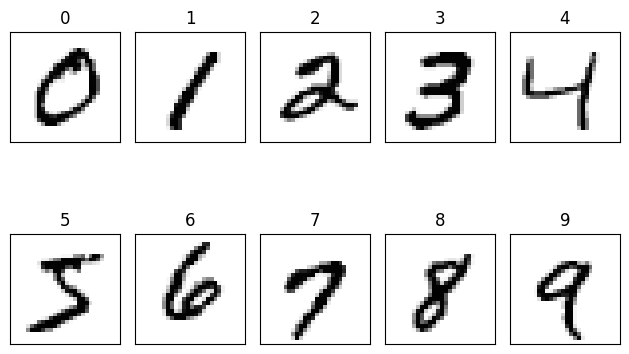

In [41]:
plot_example_digits(X, y)

## 3. Train / dev / test split and DataLoaders

- First, we follow the original dataset's convention: first 60,000 examples for train+dev, last 10,000 for test.
- Then we perform a stratified split of the training portion into:
  - a training set (90% of the first 60k)
  - a dev set (10% of the first 60k)

We need to provide the model configuration now, because the training batch size is needed by the `DataLoader`s that we are going to use to make the data available to PyTorch.


Finally, we wrap these arrays in PyTorch `Dataset`s and `DataLoader`s.


In [42]:
(X_train, y_train), (X_dev, y_dev), (X_test, y_test) = split_train_dev_test(X, y)

config = HyperParams(
    num_classes=10,
    lr=0.05,
    num_epochs=100,
    batch_size=50,
)

train_loader, dev_loader, test_loader = make_dataloaders(
    X_train,
    y_train,
    X_dev,
    y_dev,
    X_test,
    y_test,
    batch_size=config.batch_size,
    test_batch_size=16,
)

print("Train set:", X_train.shape)
print("Dev set:  ", X_dev.shape)
print("Test set: ", X_test.shape)


Train set: (54000, 1, 28, 28)
Dev set:   (6000, 1, 28, 28)
Test set:  (10000, 1, 28, 28)


## 4. Define the model and training setup

We instantiate:

- a `HyperParams` configuration object
- the `DNN` model using that configuration
- the training routine will create an SGD optimizer and CrossEntropy loss.


In [43]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
print("Using device:", device)

model = CNN(config)


Using device: mps


## 5. Train the model

We run the main training loop for `config.num_epochs`, tracking:

- average training loss and accuracy per epoch
- dev loss and accuracy per epoch


In [44]:
tr_losses, tr_accs, dev_losses, dev_accs = train_model(
    model=model,
    train_loader=train_loader,
    dev_loader=dev_loader,
    num_epochs=config.num_epochs,
    lr=config.lr,
    device=device,
    patience=25,
)


Epoch 1/100 - Train loss 0.2475, acc 0.9197 - Dev loss 0.1186, acc 0.9590
Epoch 2/100 - Train loss 0.1115, acc 0.9660 - Dev loss 0.1128, acc 0.9623
Epoch 3/100 - Train loss 0.1047, acc 0.9689 - Dev loss 0.1104, acc 0.9640
Epoch 4/100 - Train loss 0.0996, acc 0.9695 - Dev loss 0.1120, acc 0.9653
Epoch 5/100 - Train loss 0.1002, acc 0.9698 - Dev loss 0.1113, acc 0.9677
Epoch 6/100 - Train loss 0.0985, acc 0.9703 - Dev loss 0.1027, acc 0.9698
Epoch 7/100 - Train loss 0.0967, acc 0.9710 - Dev loss 0.0936, acc 0.9738
Epoch 8/100 - Train loss 0.0978, acc 0.9710 - Dev loss 0.0930, acc 0.9702
Epoch 9/100 - Train loss 0.0963, acc 0.9708 - Dev loss 0.1085, acc 0.9695
Epoch 10/100 - Train loss 0.0979, acc 0.9698 - Dev loss 0.0902, acc 0.9763
Epoch 11/100 - Train loss 0.0849, acc 0.9745 - Dev loss 0.0789, acc 0.9752
Epoch 12/100 - Train loss 0.0858, acc 0.9737 - Dev loss 0.0855, acc 0.9742
Epoch 13/100 - Train loss 0.0819, acc 0.9749 - Dev loss 0.0851, acc 0.9748
Epoch 14/100 - Train loss 0.0822, 

## 6. Plot learning curves

We visualize loss and accuracy for both training and dev sets
to see whether the model is overfitting or underfitting.


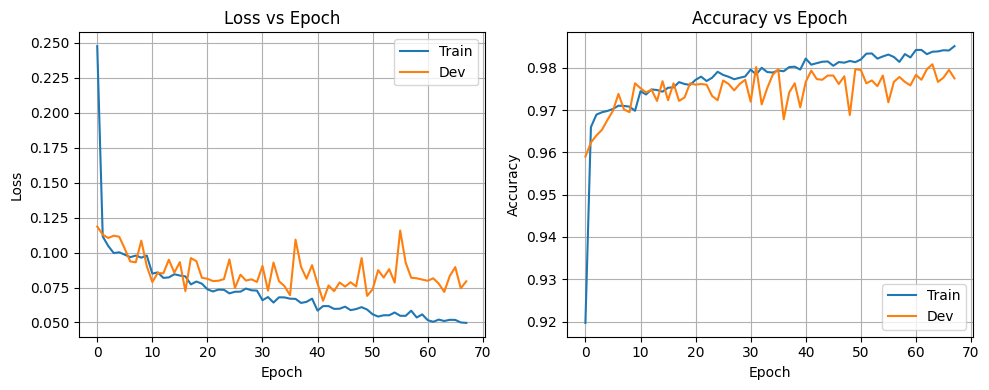

In [45]:
plot_learning_curves(tr_losses, tr_accs, dev_losses, dev_accs)

# Confusion matrix
Display a confusion matrix and a classification report showing how the classification looks on the development set. The classification report gives accuracy, as requested in the assignment.


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0    0.98367   0.98367   0.98367       980
           1    0.98253   0.99119   0.98684      1135
           2    0.98720   0.97190   0.97949      1032
           3    0.96615   0.98911   0.97750      1010
           4    0.99065   0.97149   0.98098       982
           5    0.97020   0.98543   0.97775       892
           6    0.99036   0.96555   0.97780       958
           7    0.97222   0.98735   0.97973      1028
           8    0.95964   0.97639   0.96794       974
           9    0.98075   0.95937   0.96994      1009

    accuracy                        0.97830     10000
   macro avg    0.97834   0.97814   0.97816     10000
weighted avg    0.97845   0.97830   0.97830     10000



<Figure size 800x800 with 0 Axes>

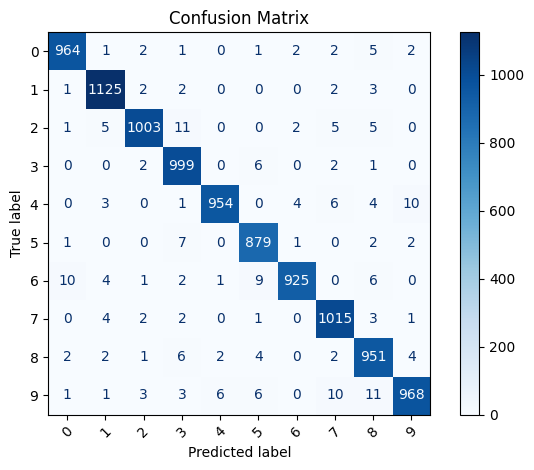

In [46]:
evaluate_and_report(model, test_loader)

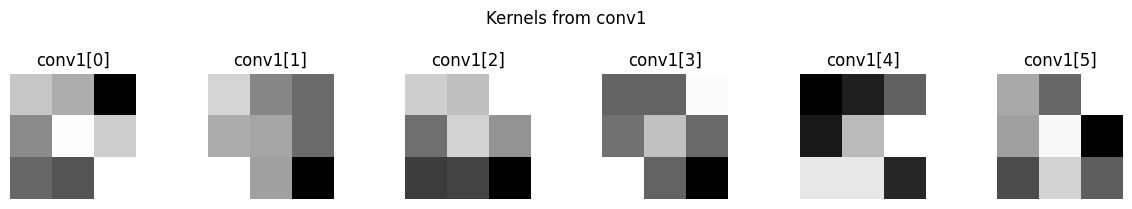

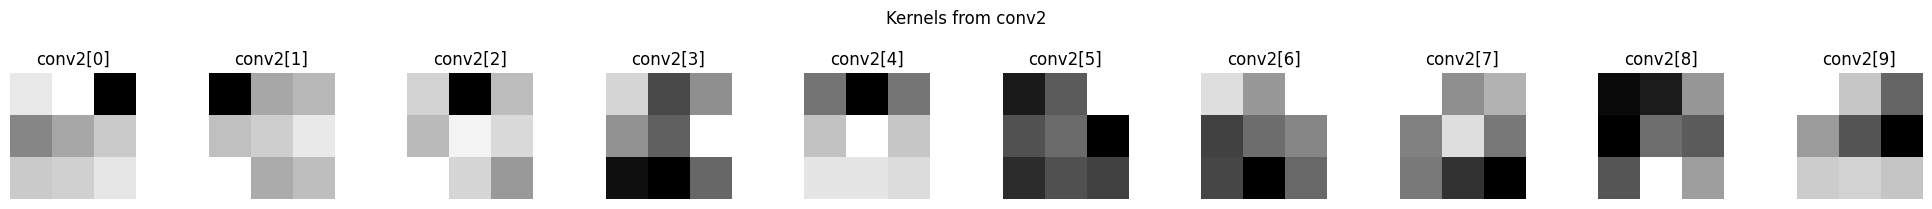

In [47]:
visualize_kernels(model, "conv1", num_kernels=6)
visualize_kernels(model, "conv2", num_kernels=10)

## Discussion of Baseline CNN Overfitting / Underfitting

The max-pooling CNN shows reduced capacity compared to the baseline, with slower training and higher, noisier dev loss. This is because the max-pooling does not converge in 100 epochs due to the noisiness of both train and dev loss. However, the gap between train and dev accuracy is much closer. The kernels are perhaps a bit simpler and less detailed than those in the baseline CNN, which would be consistent with the pooling layers removing fine-grained spatial information. Overall, the pooled model generalizes reasonably well with much higher dev accuracy, but with a little less stability than the baseline CNN.
